In [4]:
import astropy.constants as c
import astropy.units as u
from astroplan import Observer
from astropy.coordinates import SkyCoord, EarthLocation
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### Assignment 1
### Calculate the gravitational force between a 3solar mass star and its 10 Jupiter mass planet2 au away.

In [5]:
#3 güneş kütlesi olan bir yıldız ile 2 au uzaklıkta bulunan ve 
#10 Jüpiter kütlesi olan gezegeni arasındaki yerçekimi kuvvetini hesaplayınız.
import astropy.constants as c
import astropy.units as u

#kütleleri ve mesafeyi uygun astropy birimleri ve sabitleriyle tanımlayalım
m_star  = 3 * c.M_sun # 3 güneş kütlesi
m_planet  = 10 * c.M_jup #10 jüpiter kütlesi
distance = 2 * u.au # 2 au mesafe

#newtonun kütle çekim kanunu F = G (m1 * m2) / r^2
F  = c.G * m_star * m_planet / distance **2
print ("F:", F)

F: 1.889285600523636e+48 m3 kg / (AU2 s2)


### Assignment 2

In [6]:
from astropy.io import fits

#Astropy kurulumuyla birlikte gelen örnek test verisinin dosya yolunu alalım
fits_img_fn = fits.util.get_testdata_filepath('test0.fits')

#fits dosyasının header data unit listesi olarak açıyoruz
hdul = fits.open(fits_img_fn)

#dosya icindeki katmanları yazdıralım
hdul.info()

Filename: /opt/anaconda3/lib/python3.13/site-packages/astropy/io/fits/tests/data/test0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     138   ()      
  1  SCI           1 ImageHDU        61   (40, 40)   int16   
  2  SCI           2 ImageHDU        61   (40, 40)   int16   
  3  SCI           3 ImageHDU        61   (40, 40)   int16   
  4  SCI           4 ImageHDU        61   (40, 40)   int16   


### Assignment 3
### You have to plan an observation of Fomalhaut from Subaru. The first step is to generate the coordinates of the star and the observing site. The packages here are a hint

In [7]:
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astroplan import Observer

In [8]:
# Fomalhaut yıldızının koordinatlarını isminden bulma
fomalhaut = SkyCoord.from_name('FomalHaut')

#Subaru gözlemevinin konumunu ve saat dilimini tanımlama
subaru = Observer.at_site('Subaru', timezone = 'US/Hawaii')
subaru_loc = EarthLocation(lat=subaru.latitude, lon=subaru.longitude)

print(f"Sky Coords of Fomalhaut: {fomalhaut} and Geocentric Coords of Subaru: {subaru_loc}")

Sky Coords of Fomalhaut: <SkyCoord (ICRS): (ra, dec) in deg
    (344.41269272, -29.62223703)> and Geocentric Coords of Subaru: (-5460925.685460801, -2491437.4906419897, 2149539.8319970635) m


### Assignment 4
### There are other tools you need like astropy.time and astropy.visualization to plot and visualize the night-time observability

In [9]:
from astropy.time import Time
from astroplan.plots import plot_airmass

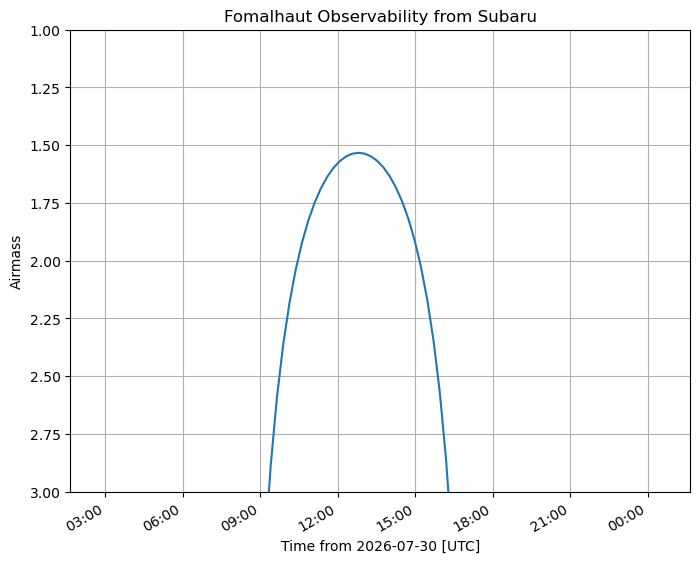

In [10]:
# Gözlem Zamanını Belirleme 
observe_time = Time.now()

# Gece Boyunca Hava Kütlesi Grafiğini Çizdirme
plt.figure(figsize=(8, 6))
plot_airmass(fomalhaut, subaru, observe_time)
plt.title('Fomalhaut Observability from Subaru')
plt.grid(True)
plt.show()

## Scipy

### Assignment 5: Try 2D interpolation; i.e. interpolate data that is a 2D array


In [14]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np

#x ve y eksenlerinde grid koordinatlarını tanımlıyoruz
x = np.array([0,5,10])
y = np.array([0,5,10])

# 2 boyutlu örnek veri matrisini oluştualım 3x3 dizi
# x=0, y=0 -> 10
# x=0, y=1 -> 40
# x=0, y=2 -> 20
# x=1, y=0 -> 20
#x=1, y=1 -> 50
#x=1, y=2 -> 80
data = np.array([[10,20,30],
               [40,50,60],
               [70,80,90]])

#RegularGridInterpolator fonksiyonu ile interpolasyon nesnesi kuralım
interpolation_func = RegularGridInterpolator((x,y), data)

#öğrenmek istediğimiz ara değerleri belirtelim (0-10 arasında)
new_points = ([[2.5, 2.5],
              [7.0, 3.0]])

#yeni noktalardaki interpolated (enterpolasyonlu) değerlerini hesaplıyoruz
interpolated_values = interpolation_func(new_points)
print(f"Interpolated values at the new points: {interpolated_values}")

Interpolated values at the new points: [30. 58.]


## Numpy

### Assignment: Take a noisy frame and a target list. Mask the hot pixels out of a fake image, then filter a small target list.
#### 1. mask everything more than 3 sigma above the median
#### 2. print the mean before and after. how much did it move?
#### 3. print the targets with dec > -10, then the mean kmag per filter

In [20]:
import numpy as np
import pandas as pd

#verilen hazırlık kodları
rng = np.random.default_rng(42)
img = rng.normal(100, 5, (64, 64))  # sahte gökyüzü karesi
img[10, 20] = 5000 # sıcak (hatalı) piksel

cat = pd.DataFrame({
    'name': ['V883 Ori', 'BN/KL', 'Fomalhaut', 'HD 214734', 'AB Aur'],
    'ra': [83.05, 83.81, 344.41, 226.62, 73.94],
    'dec': [-7.15, -5.37, -29.62, 61.30, 30.55],
    'kmag': [8.4, 6.1, 0.9, 7.2, 4.2],
    'filt': ['Ks', 'Ks', 'H', 'Ks', 'H'],
})

# 1. Maskeleme (Medyanın 3 sigma üstündeki her şeyi maskeleme)
median_val = np.median(img)
std_val = np.std(img)
threshold = median_val + 3 * std_val
# Maskelenmiş bir numpy masked array oluşturuyoruz veya anormal değeri filtreliyoruz
masked_img = np.ma.masked_greater(img, threshold)

# 2. Öncesi ve sonrası ortalamayı yazdırma ve ne kadar değiştiğini görmek
mean_before = np.mean(img)
mean_after = np.mean(masked_img) # masked array ortalaması hatalı pikseli dışarıda bırakır
print(f"Mean before: {mean_before:.4f}")
print(f"Mean after: {mean_after:.4f}")
print(f"Difference (how much it moved): {abs(mean_before - mean_after):.4f}")
print()

#3. dec > -10 olan hedefleri filtreleme ve filtre başına ortalama kmag hesaplama
filtered = cat[cat['dec'] > -10]
print("\nTargets with dec > -10:")
print(filtered)

mean_kmag_filter = cat.groupby('filt')['kmag'].mean()
print("\nMean kmag per filter:")
print(mean_kmag_filter)

Mean before: 101.1015
Mean after: 99.9051
Difference (how much it moved): 1.1963


Targets with dec > -10:
        name      ra    dec  kmag filt
0   V883 Ori   83.05  -7.15   8.4   Ks
1      BN/KL   83.81  -5.37   6.1   Ks
3  HD 214734  226.62  61.30   7.2   Ks
4     AB Aur   73.94  30.55   4.2    H

Mean kmag per filter:
filt
H     2.550000
Ks    7.233333
Name: kmag, dtype: float64
